# Section 1: Environment Setup, Paths & Data Loading

In [26]:
import os
import joblib
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# 2. Define path to your project folder in Google Drive
# Update 'Telecom_Cell_Outage_Project' to your exact Drive folder name
# PROJECT_DIR should be a directory, not a file.
PROJECT_DIR = '/content/drive/MyDrive'

# DATA_PATH should now directly point to your dataset file.
DATA_PATH = os.path.join(PROJECT_DIR, 'mobi_data2_final_engineered.csv')

# MODELS_DIR will now correctly be '/content/drive/MyDrive/models'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')

os.makedirs(MODELS_DIR, exist_ok=True)

# 3. Load Featured Dataset
print(f"Loading dataset from: {DATA_PATH}")
if DATA_PATH.endswith('.parquet'):
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print(f"Dataset successfully loaded. Shape: {df.shape}")

Loading dataset from: /content/drive/MyDrive/mobi_data2_final_engineered.csv
Dataset successfully loaded. Shape: (999999, 23)


# Section 2: Stratified Split & Multi-Model Training Pipeline


                DATA LEAKAGE & INTEGRITY AUDIT REPORT               

--- Check 1: Target Leakage (High Signal Features) ---
✅ PASSED: No individual feature shows unrealistic correlation with target.

--- Check 2: Unique ID & High-Cardinality Memorization Leakage ---
✅ PASSED: No high-cardinality metadata or ID columns found in feature matrix.

🎉 AUDIT PASSED: Data structure is clean for training!
Training Set:   699,999 rows (70.0%) | 699,999 Unique Entities
Validation Set: 150,000 rows (15.0%) | 150,000 Unique Entities
Test Set:       150,000 rows (15.0%) | 150,000 Unique Entities
Calculated Imbalance Ratio (scale_pos_weight): 8.4083

--- Starting Fast Hyperparameter Tuning on 100,000 Sampled Rows ---
Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Tuning XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Fitting Tuned Models on Full Dataset ---
Fitting LightGBM...
Fitting XGBoost...
Fitting RandomForest...

--- Computing Mul

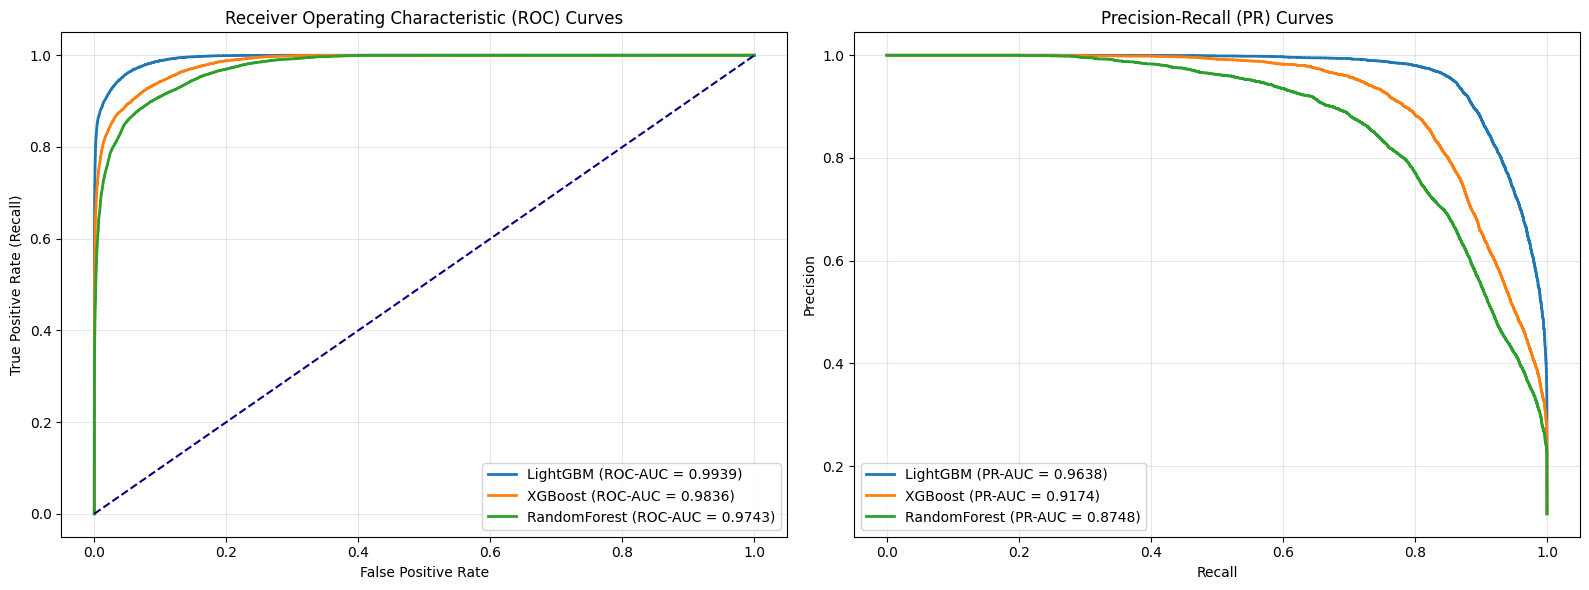


--- Decision Threshold Tuning (LightGBM) ---
Optimal Probability Threshold (tuned on X_val): 0.7831
-------------------------------------------------------
  Accuracy @ Optimal Threshold:  0.9801
  Precision @ Optimal Threshold: 0.9491
  Recall @ Optimal Threshold:    0.8601
  F1-Score @ Optimal Threshold:  0.9024
  ROC-AUC Score:                0.9939
-------------------------------------------------------

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0     0.9834    0.9945    0.9889    133954
           1     0.9491    0.8601    0.9024     16046

    accuracy                         0.9801    150000
   macro avg     0.9663    0.9273    0.9457    150000
weighted avg     0.9798    0.9801    0.9797    150000



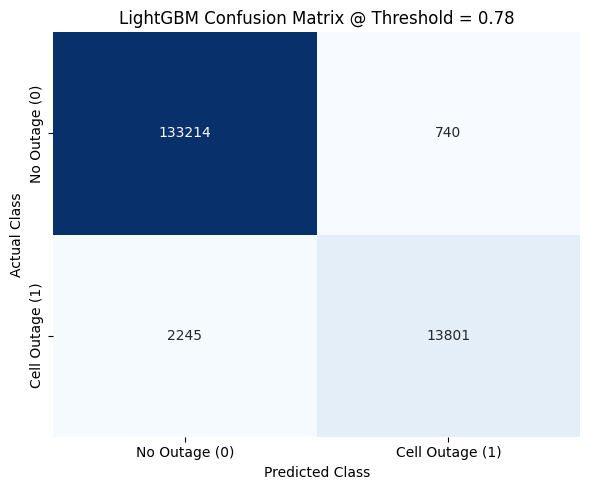


Champion model successfully exported to ./models/champion_model.joblib


In [25]:
# =========================================================
# Section 1: Environment Setup, Libraries & Audit Engine
# =========================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix, mutual_info_score
)
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# Define Local Storage Paths
MODELS_DIR = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

def run_data_leakage_audit(df, target_col='target'):
    """
    Scans dataset for target leakage and high-cardinality ID memorization.
    Explicitly ignores valid encoded domain features with low unique ratios.
    """
    print("=" * 70)
    print("                DATA LEAKAGE & INTEGRITY AUDIT REPORT               ")
    print("=" * 70)

    leakage_flags = 0
    features = [c for c in df.columns if c != target_col]

    # 1. Target Leakage Check (Suspicious Correlation/Mutual Info)
    print("\n--- Check 1: Target Leakage (High Signal Features) ---")
    suspicious_features = []
    for col in features:
        if pd.api.types.is_numeric_dtype(df[col]):
            corr = abs(df[col].corr(df[target_col]))
            if corr > 0.85:
                suspicious_features.append((col, f"Correlation: {corr:.4f}"))
        else:
            mi = mutual_info_score(df[col].astype(str), df[target_col].astype(str))
            if mi > 0.5:
                suspicious_features.append((col, f"Mutual Info: {mi:.4f}"))

    if suspicious_features:
        leakage_flags += 1
        print("⚠️ HIGH RISK: The following features have suspiciously high target alignment:")
        for feat, score in suspicious_features:
            print(f"   - {feat:<30} | {score}")
    else:
        print("✅ PASSED: No individual feature shows unrealistic correlation with target.")

    # 2. Metadata & High-Cardinality ID Check
    print("\n--- Check 2: Unique ID & High-Cardinality Memorization Leakage ---")
    flagged_ids = []

    for col in features:
        unique_ratio = df[col].nunique() / len(df)
        n_uniques = df[col].nunique()

        # Flag if column unique ratio > 50% OR if it contains ID keywords AND has >100 unique values
        if unique_ratio > 0.5 or (any(kw in col.lower() for kw in ['id', 'serial', 'key']) and n_uniques > 100):
            flagged_ids.append((col, f"Uniques: {n_uniques:,} ({unique_ratio:.2%})"))

    if flagged_ids:
        leakage_flags += 1
        print("⚠️ WARNING: Potential ID/Metadata features detected in feature matrix 'X':")
        for col, info in flagged_ids:
            print(f"   - {col:<30} | {info}")
    else:
        print("✅ PASSED: No high-cardinality metadata or ID columns found in feature matrix.")

    print("\n" + "=" * 70)
    if leakage_flags > 0:
        print(f"🚨 AUDIT FAILED: Found {leakage_flags} potential data leakage vector(s).")
    else:
        print("🎉 AUDIT PASSED: Data structure is clean for training!")
    print("=" * 70)

# =========================================================
# Section 2: Feature Sanitization & Leakage Audit
# =========================================================

# Preserve grouping identifier for splitting BEFORE dropping
if 'mo_name' in df.columns:
    group_identifier = df['mo_name'].copy()
elif 'enodeb_id' in df.columns:
    group_identifier = df['enodeb_id'].copy()
else:
    group_identifier = pd.Series(np.arange(len(df)))

# Drop ALL entity IDs (including mo_name_encoded) to prevent tree memorization
metadata_to_drop = [
    'location_information', 'additional_information',
    'enodeb_id', 'gnodeb_id', 'mo_name', 'alarm_id',
    'mo_name_encoded', 'enodeb_id_encoded', 'cell_id', 'site_id'
]

X = df.drop(columns=[c for c in metadata_to_drop if c in df.columns], errors='ignore')

if 'target' in X.columns:
    y = X['target']
    X = X.drop(columns=['target'])
else:
    raise KeyError("Target column 'target' not found in dataset!")

# Ensure remaining object/category features are explicitly typed
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# Execute Data Audit on Sanitized DataFrame
audit_df = pd.concat([X, y], axis=1)
run_data_leakage_audit(audit_df, target_col='target')

# =========================================================
# Section 3: Zero-Leakage Group-Based Split (70 / 15 / 15)
# =========================================================

# Step 1: Hold out 15% strict Test set grouped by Tower/Cell entity
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X, y, groups=group_identifier))

X_train_val, y_train_val = X.iloc[train_val_idx], y.iloc[train_val_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
groups_train_val = group_identifier.iloc[train_val_idx]

# Step 2: Split remaining 85% into ~70% Train and ~15% Validation
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.17647, random_state=42)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=groups_train_val))

X_train, y_train = X_train_val.iloc[train_idx], y_train_val.iloc[train_idx]
X_val, y_val = X_train_val.iloc[val_idx], y_train_val.iloc[val_idx]

# Calculate class imbalance ratio strictly on X_train
scale_pos = float((len(y_train) - sum(y_train)) / max(sum(y_train), 1))

print(f"Training Set:   {X_train.shape[0]:>7,} rows ({X_train.shape[0]/len(X):.1%}) | {group_identifier.iloc[train_idx].nunique():,} Unique Entities")
print(f"Validation Set: {X_val.shape[0]:>7,} rows ({X_val.shape[0]/len(X):.1%}) | {group_identifier.iloc[val_idx].nunique():,} Unique Entities")
print(f"Test Set:       {X_test.shape[0]:>7,} rows ({X_test.shape[0]/len(X):.1%}) | {group_identifier.iloc[test_idx].nunique():,} Unique Entities")
print(f"Calculated Imbalance Ratio (scale_pos_weight): {scale_pos:.4f}\n")

# =========================================================
# Section 4: Subsampled Hyperparameter Tuning
# =========================================================

tuning_sample_size = min(100000, len(X_train))
# Subsample for tuning while preserving group independence
gss_sample = GroupShuffleSplit(n_splits=1, train_size=tuning_sample_size, random_state=42)
sample_idx, _ = next(gss_sample.split(X_train, y_train, groups=group_identifier.iloc[train_idx]))

X_train_sample = X_train.iloc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'scale_pos_weight': [scale_pos]
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'scale_pos_weight': [scale_pos]
}

print(f"--- Starting Fast Hyperparameter Tuning on {len(X_train_sample):,} Sampled Rows ---")

print("Tuning LightGBM...")
lgb_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=1, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_train_sample, y_train_sample)

print("\nTuning XGBoost...")
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(tree_method='hist', enable_categorical=True, random_state=42, n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_sample, y_train_sample)

best_lgb = lgb_search.best_estimator_
best_lgb.set_params(n_jobs=-1)

best_xgb = xgb_search.best_estimator_
best_xgb.set_params(n_jobs=-1)

rf_baseline = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced',
    random_state=42, n_jobs=-1
)

models = {
    'LightGBM': best_lgb,
    'XGBoost': best_xgb,
    'RandomForest': rf_baseline
}

# =========================================================
# Section 5: Model Fitting on Full Dataset
# =========================================================

trained_models = {}

print("\n--- Fitting Tuned Models on Full Dataset ---")
for name, model in models.items():
    print(f"Fitting {name}...")

    if name == 'LightGBM':
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)]
        )
    elif name == 'XGBoost':
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

# Save splits & trained models
joblib.dump(trained_models, os.path.join(MODELS_DIR, 'all_trained_models.joblib'))
joblib.dump({'X_train': X_train, 'X_val': X_val, 'X_test': X_test, 'y_test': y_test},
            os.path.join(MODELS_DIR, 'test_data_split.joblib'))

# =========================================================
# Section 6: Evaluation Scorecard & ROC / PR Plotting
# =========================================================

model_scorecard = []
print("\n--- Computing Multi-Model Metrics on Unseen Test Set ---")

for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)

    model_scorecard.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, y_probs), 4)
    })

scorecard_df = pd.DataFrame(model_scorecard).sort_values(by='PR-AUC', ascending=False)
print("\n" + "="*70)
print("             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            ")
print("="*70)
print(scorecard_df.to_string(index=False))

# Plot ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]

    # ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (ROC-AUC = {roc_auc_score(y_test, y_probs):.4f})')

    # PR Curves
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_probs):.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 7: Threshold Optimization & Export
# =========================================================

champion_name = scorecard_df.iloc[0]['Model']
champion_model = trained_models[champion_name]

print(f"\n--- Decision Threshold Tuning ({champion_name}) ---")

# Step 1: Tune optimal threshold on Validation set (X_val)
val_probs = champion_model.predict_proba(X_val)[:, 1]
val_prec, val_rec, val_thresh = precision_recall_curve(y_val, val_probs)
f1_val = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-10)
best_idx = np.argmax(f1_val)

optimal_threshold = val_thresh[min(best_idx, len(val_thresh) - 1)]

# Step 2: Apply threshold to unseen Test set (X_test)
y_probs_champ = champion_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_probs_champ >= optimal_threshold).astype(int)

opt_acc = accuracy_score(y_test, y_pred_optimal)
opt_prec = precision_score(y_test, y_pred_optimal, zero_division=0)
opt_rec = recall_score(y_test, y_pred_optimal, zero_division=0)
opt_f1 = f1_score(y_test, y_pred_optimal, zero_division=0)
opt_roc_auc = roc_auc_score(y_test, y_probs_champ)

print(f"Optimal Probability Threshold (tuned on X_val): {optimal_threshold:.4f}")
print("-" * 55)
print(f"  Accuracy @ Optimal Threshold:  {opt_acc:.4f}")
print(f"  Precision @ Optimal Threshold: {opt_prec:.4f}")
print(f"  Recall @ Optimal Threshold:    {opt_rec:.4f}")
print(f"  F1-Score @ Optimal Threshold:  {opt_f1:.4f}")
print(f"  ROC-AUC Score:                {opt_roc_auc:.4f}")
print("-" * 55)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Outage (0)', 'Cell Outage (1)'],
            yticklabels=['No Outage (0)', 'Cell Outage (1)'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'{champion_name} Confusion Matrix @ Threshold = {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

# Export Champion Model Artifacts
joblib.dump({
    'model_name': champion_name,
    'model': champion_model,
    'threshold': optimal_threshold,
    'features': list(X_train.columns)
}, os.path.join(MODELS_DIR, 'champion_model.joblib'))

print(f"\nChampion model successfully exported to {MODELS_DIR}/champion_model.joblib")

#Model Evaluation


--- Computing Multi-Model Performance Metrics on Holdout Test Set ---

             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
    LightGBM    0.9547     0.7158  0.9559    0.8186   0.9939  0.9638
     XGBoost    0.9257     0.5992  0.9215    0.7262   0.9836  0.9174
RandomForest    0.9241     0.5982  0.8844    0.7137   0.9743  0.8748

--- Plotting Loss Curves ---


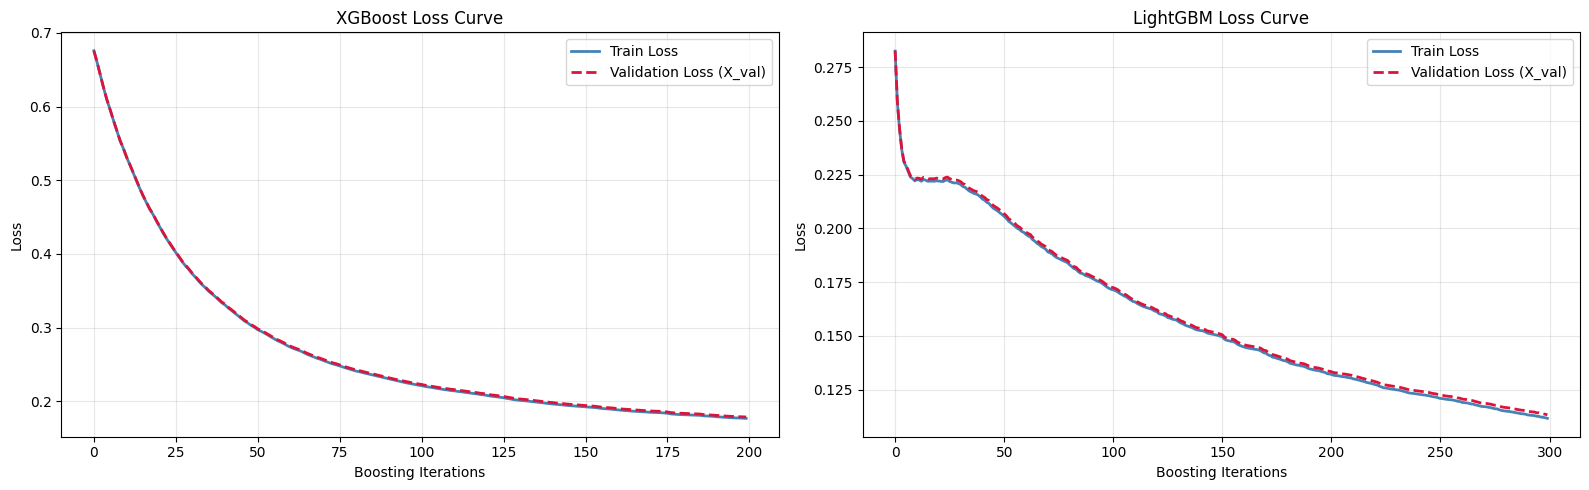

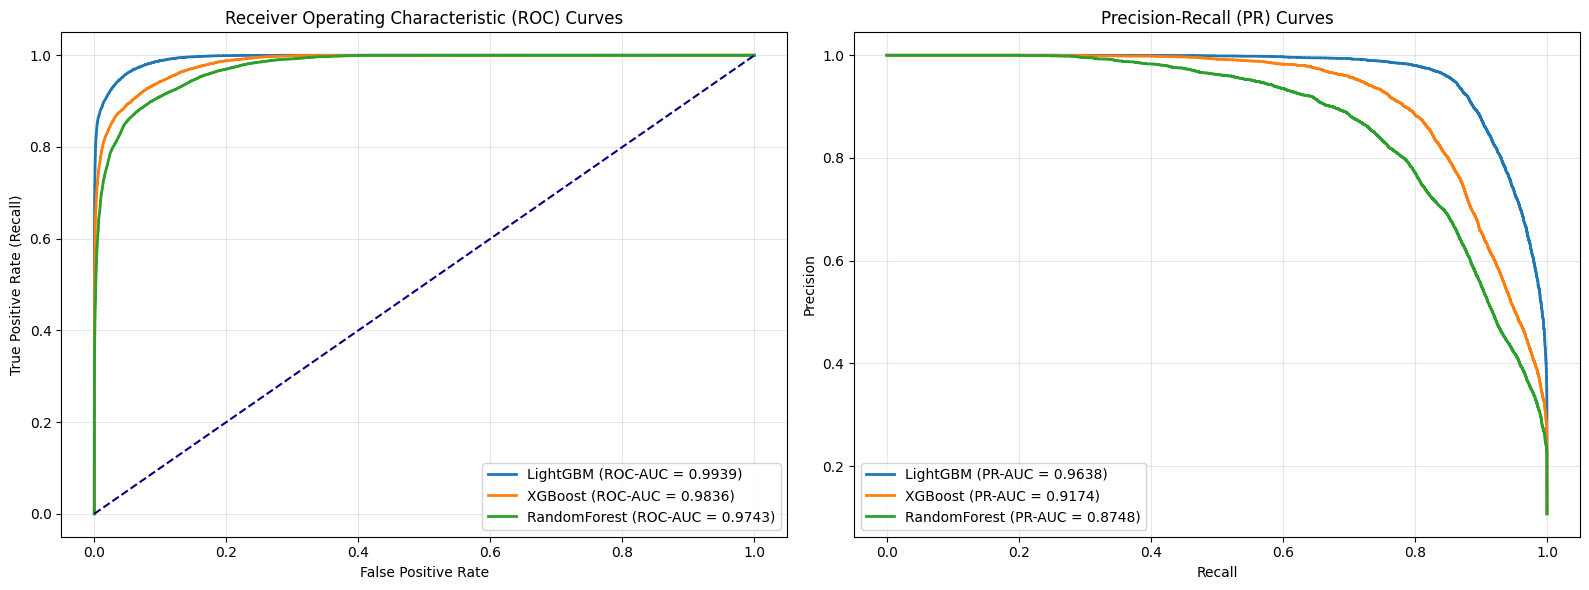


--- Decision Threshold Tuning (LightGBM) ---
Optimal Probability Threshold (tuned on X_val): 0.7831
-------------------------------------------------------
  Accuracy @ Optimal Threshold:  0.9801
  Precision @ Optimal Threshold: 0.9491
  Recall @ Optimal Threshold:    0.8601
  F1-Score @ Optimal Threshold:  0.9024
  ROC-AUC Score:                0.9939
-------------------------------------------------------

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0     0.9834    0.9945    0.9889    133954
           1     0.9491    0.8601    0.9024     16046

    accuracy                         0.9801    150000
   macro avg     0.9663    0.9273    0.9457    150000
weighted avg     0.9798    0.9801    0.9797    150000



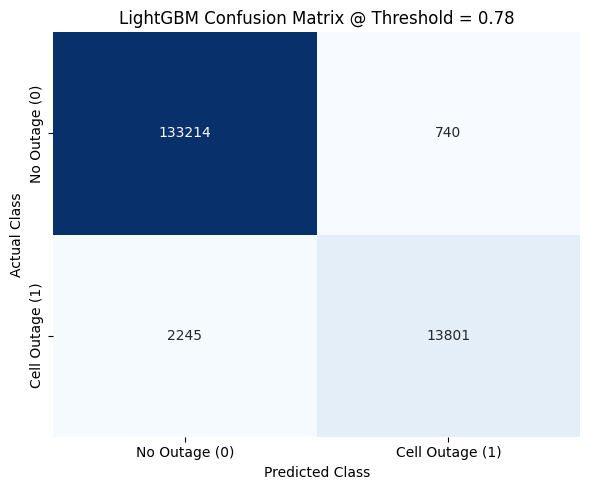


Champion model exported successfully to /content/drive/MyDrive/models/champion_model.joblib

--- Computing Multi-Model Performance Metrics on Holdout Test Set ---

             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
    LightGBM    0.9547     0.7158  0.9559    0.8186   0.9939  0.9638
     XGBoost    0.9257     0.5992  0.9215    0.7262   0.9836  0.9174
RandomForest    0.9241     0.5982  0.8844    0.7137   0.9743  0.8748

--- Plotting Loss Curves ---


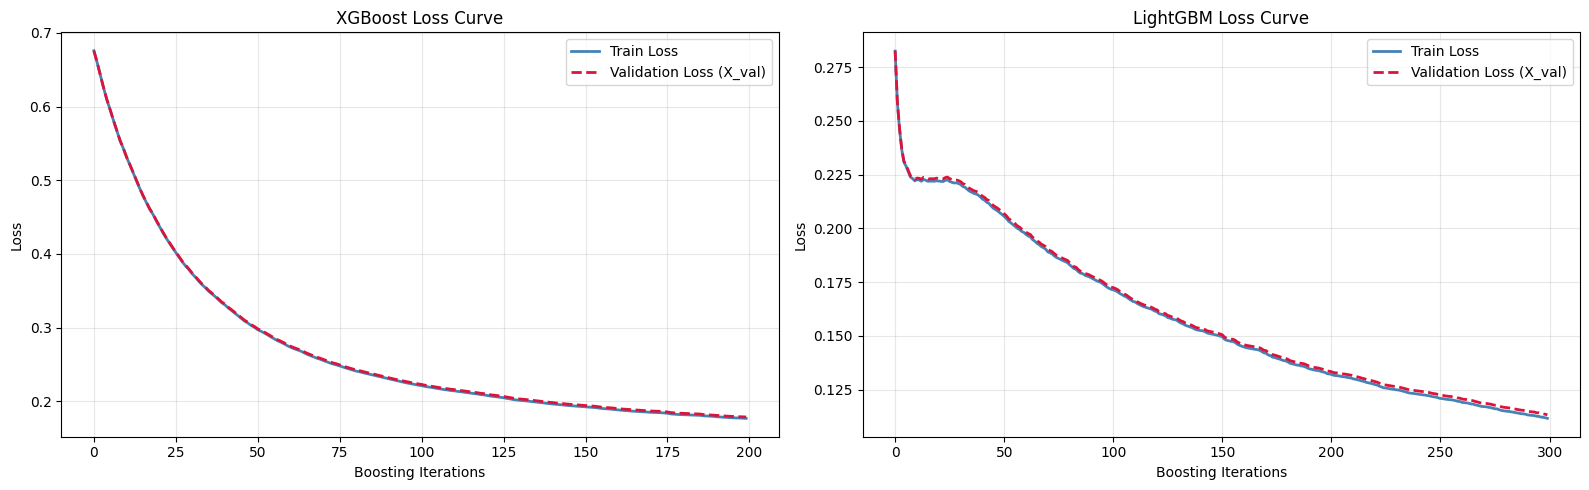

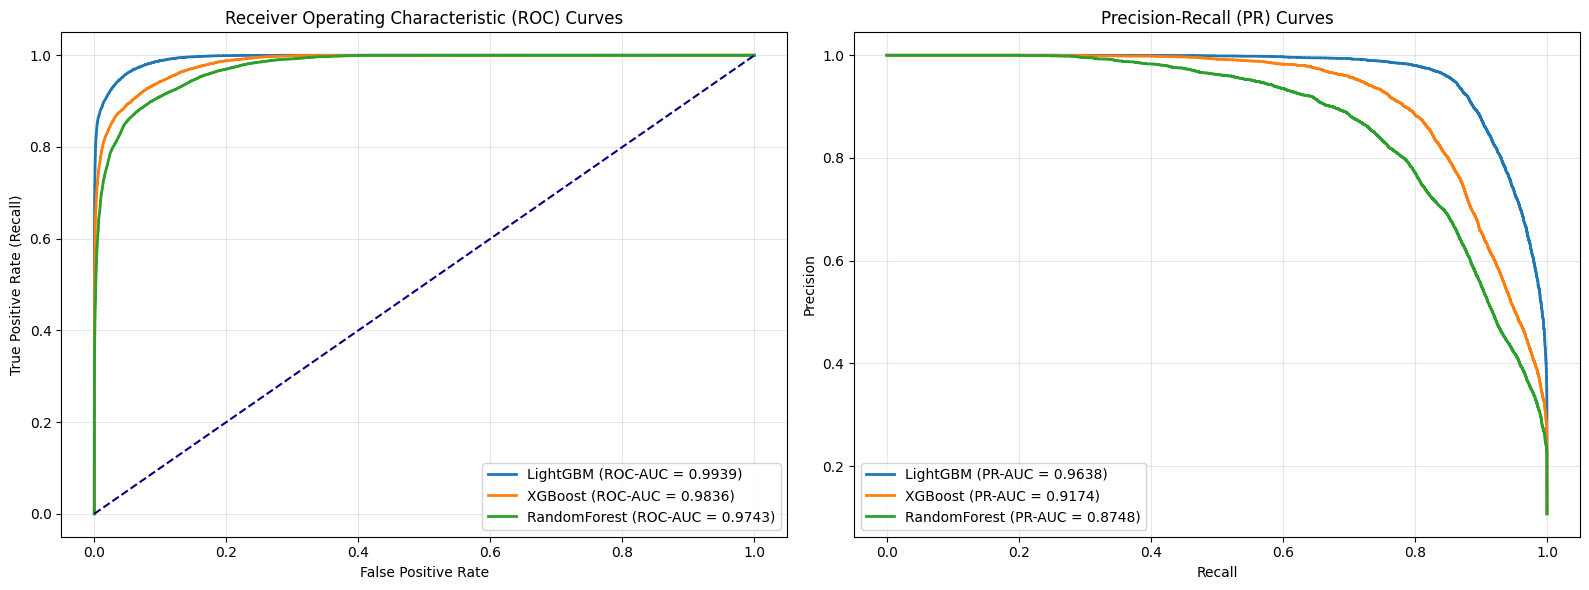


--- Decision Threshold Tuning (LightGBM) ---
Optimal Probability Threshold (tuned on X_val): 0.7831
-------------------------------------------------------
  Accuracy @ Optimal Threshold:  0.9801
  Precision @ Optimal Threshold: 0.9491
  Recall @ Optimal Threshold:    0.8601
  F1-Score @ Optimal Threshold:  0.9024
  ROC-AUC Score:                0.9939
-------------------------------------------------------

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0     0.9834    0.9945    0.9889    133954
           1     0.9491    0.8601    0.9024     16046

    accuracy                         0.9801    150000
   macro avg     0.9663    0.9273    0.9457    150000
weighted avg     0.9798    0.9801    0.9797    150000



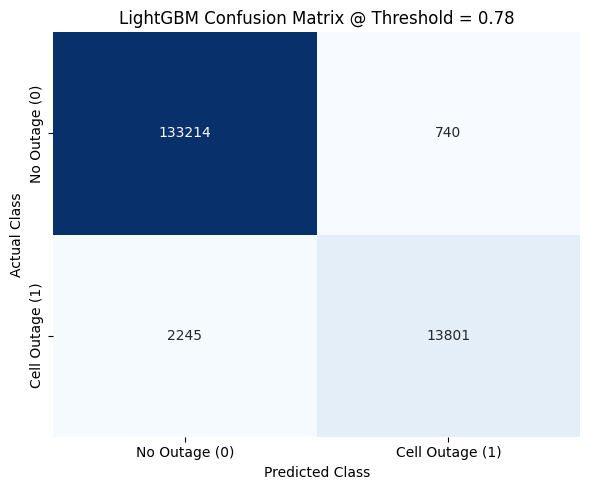


Champion model exported successfully to /content/drive/MyDrive/models/champion_model.joblib


In [28]:
# =========================================================
# Section 5: Cache Probabilities & Multi-Model Scorecard
# =========================================================

# Cache predictions to avoid redundant model calls across plots/metrics
test_probabilities = {}
for name, model in trained_models.items():
    test_probabilities[name] = model.predict_proba(X_test)[:, 1]

model_scorecard = []
print("\n--- Computing Multi-Model Performance Metrics on Holdout Test Set ---")

for name, y_probs in test_probabilities.items():
    y_pred = (y_probs >= 0.5).astype(int)

    model_scorecard.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, y_probs), 4)
    })

scorecard_df = pd.DataFrame(model_scorecard).sort_values(by='PR-AUC', ascending=False)

print("\n" + "="*70)
print("             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            ")
print("="*70)
print(scorecard_df.to_string(index=False))

# =========================================================
# Section 6: Robust Training vs Validation Loss Curves
# =========================================================

print("\n--- Plotting Loss Curves ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot XGBoost Loss Curve
if 'XGBoost' in trained_models and hasattr(trained_models['XGBoost'], 'evals_result'):
    try:
        xgb_hist = trained_models['XGBoost'].evals_result()
        train_key, val_key = list(xgb_hist.keys())[0], list(xgb_hist.keys())[1]
        metric_key = list(xgb_hist[train_key].keys())[0]

        axes[0].plot(xgb_hist[train_key][metric_key], label='Train Loss', color='steelblue', lw=2)
        axes[0].plot(xgb_hist[val_key][metric_key], label='Validation Loss (X_val)', color='crimson', lw=2, linestyle='--')
        axes[0].set_xlabel('Boosting Iterations')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('XGBoost Loss Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    except Exception as e:
        axes[0].text(0.5, 0.5, f"Could not render XGBoost loss:\n{e}", ha='center', va='center')

# Plot LightGBM Loss Curve (Handles sklearn API evaluation keys reliably)
if 'LightGBM' in trained_models and hasattr(trained_models['LightGBM'], 'evals_result_'):
    try:
        lgb_hist = trained_models['LightGBM'].evals_result_
        train_key, val_key = list(lgb_hist.keys())[0], list(lgb_hist.keys())[1]
        metric_key = list(lgb_hist[train_key].keys())[0]

        axes[1].plot(lgb_hist[train_key][metric_key], label='Train Loss', color='steelblue', lw=2)
        axes[1].plot(lgb_hist[val_key][metric_key], label='Validation Loss (X_val)', color='crimson', lw=2, linestyle='--')
        axes[1].set_xlabel('Boosting Iterations')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('LightGBM Loss Curve')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    except Exception as e:
        axes[1].text(0.5, 0.5, f"Could not render LightGBM loss:\n{e}", ha='center', va='center')

plt.tight_layout()
plt.show()

# =========================================================
# Section 7: ROC and Precision-Recall Curves Plotting
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, y_probs in test_probabilities.items():
    # ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (ROC-AUC = {roc_auc_score(y_test, y_probs):.4f})')

    # PR Curves
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_probs):.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 8: Zero-Leakage Threshold Optimization & Export
# =========================================================

champion_name = scorecard_df.iloc[0]['Model']
champion_model = trained_models[champion_name]

print(f"\n--- Decision Threshold Tuning ({champion_name}) ---")

# Step 1: Tune optimal threshold on Validation set (X_val)
val_probs = champion_model.predict_proba(X_val)[:, 1]
val_prec, val_rec, val_thresh = precision_recall_curve(y_val, val_probs)

# Compute F1 on val set with epsilon to prevent zero-division
f1_val = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-10)
best_idx = np.argmax(f1_val)

# Handle boundary condition: precision_recall_curve returns thresh of len (n - 1)
optimal_threshold = val_thresh[min(best_idx, len(val_thresh) - 1)]

# Step 2: Apply threshold to unseen Test set (X_test) via cached probabilities
y_probs_champ = test_probabilities[champion_name]
y_pred_optimal = (y_probs_champ >= optimal_threshold).astype(int)

opt_acc = accuracy_score(y_test, y_pred_optimal)
opt_prec = precision_score(y_test, y_pred_optimal, zero_division=0)
opt_rec = recall_score(y_test, y_pred_optimal, zero_division=0)
opt_f1 = f1_score(y_test, y_pred_optimal, zero_division=0)
opt_roc_auc = roc_auc_score(y_test, y_probs_champ)

print(f"Optimal Probability Threshold (tuned on X_val): {optimal_threshold:.4f}")
print("-" * 55)
print(f"  Accuracy @ Optimal Threshold:  {opt_acc:.4f}")
print(f"  Precision @ Optimal Threshold: {opt_prec:.4f}")
print(f"  Recall @ Optimal Threshold:    {opt_rec:.4f}")
print(f"  F1-Score @ Optimal Threshold:  {opt_f1:.4f}")
print(f"  ROC-AUC Score:                {opt_roc_auc:.4f}")
print("-" * 55)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Outage (0)', 'Cell Outage (1)'],
            yticklabels=['No Outage (0)', 'Cell Outage (1)'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'{champion_name} Confusion Matrix @ Threshold = {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

# Export Champion Model Artifacts safely
joblib.dump({
    'model_name': champion_name,
    'model': champion_model,
    'threshold': optimal_threshold,
    'features': list(X_test.columns)
}, os.path.join(MODELS_DIR, 'champion_model.joblib'))

print(f"\nChampion model exported successfully to {MODELS_DIR}/champion_model.joblib")# =========================================================
# Section 5: Cache Probabilities & Multi-Model Scorecard
# =========================================================

# Cache predictions to avoid redundant model calls across plots/metrics
test_probabilities = {}
for name, model in trained_models.items():
    test_probabilities[name] = model.predict_proba(X_test)[:, 1]

model_scorecard = []
print("\n--- Computing Multi-Model Performance Metrics on Holdout Test Set ---")

for name, y_probs in test_probabilities.items():
    y_pred = (y_probs >= 0.5).astype(int)

    model_scorecard.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, y_probs), 4)
    })

scorecard_df = pd.DataFrame(model_scorecard).sort_values(by='PR-AUC', ascending=False)

print("\n" + "="*70)
print("             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            ")
print("="*70)
print(scorecard_df.to_string(index=False))

# =========================================================
# Section 6: Robust Training vs Validation Loss Curves
# =========================================================

print("\n--- Plotting Loss Curves ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot XGBoost Loss Curve
if 'XGBoost' in trained_models and hasattr(trained_models['XGBoost'], 'evals_result'):
    try:
        xgb_hist = trained_models['XGBoost'].evals_result()
        train_key, val_key = list(xgb_hist.keys())[0], list(xgb_hist.keys())[1]
        metric_key = list(xgb_hist[train_key].keys())[0]

        axes[0].plot(xgb_hist[train_key][metric_key], label='Train Loss', color='steelblue', lw=2)
        axes[0].plot(xgb_hist[val_key][metric_key], label='Validation Loss (X_val)', color='crimson', lw=2, linestyle='--')
        axes[0].set_xlabel('Boosting Iterations')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('XGBoost Loss Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    except Exception as e:
        axes[0].text(0.5, 0.5, f"Could not render XGBoost loss:\n{e}", ha='center', va='center')

# Plot LightGBM Loss Curve (Handles sklearn API evaluation keys reliably)
if 'LightGBM' in trained_models and hasattr(trained_models['LightGBM'], 'evals_result_'):
    try:
        lgb_hist = trained_models['LightGBM'].evals_result_
        train_key, val_key = list(lgb_hist.keys())[0], list(lgb_hist.keys())[1]
        metric_key = list(lgb_hist[train_key].keys())[0]

        axes[1].plot(lgb_hist[train_key][metric_key], label='Train Loss', color='steelblue', lw=2)
        axes[1].plot(lgb_hist[val_key][metric_key], label='Validation Loss (X_val)', color='crimson', lw=2, linestyle='--')
        axes[1].set_xlabel('Boosting Iterations')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('LightGBM Loss Curve')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    except Exception as e:
        axes[1].text(0.5, 0.5, f"Could not render LightGBM loss:\n{e}", ha='center', va='center')

plt.tight_layout()
plt.show()

# =========================================================
# Section 7: ROC and Precision-Recall Curves Plotting
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, y_probs in test_probabilities.items():
    # ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (ROC-AUC = {roc_auc_score(y_test, y_probs):.4f})')

    # PR Curves
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_probs):.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 8: Zero-Leakage Threshold Optimization & Export
# =========================================================

champion_name = scorecard_df.iloc[0]['Model']
champion_model = trained_models[champion_name]

print(f"\n--- Decision Threshold Tuning ({champion_name}) ---")

# Step 1: Tune optimal threshold on Validation set (X_val)
val_probs = champion_model.predict_proba(X_val)[:, 1]
val_prec, val_rec, val_thresh = precision_recall_curve(y_val, val_probs)

# Compute F1 on val set with epsilon to prevent zero-division
f1_val = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-10)
best_idx = np.argmax(f1_val)

# Handle boundary condition: precision_recall_curve returns thresh of len (n - 1)
optimal_threshold = val_thresh[min(best_idx, len(val_thresh) - 1)]

# Step 2: Apply threshold to unseen Test set (X_test) via cached probabilities
y_probs_champ = test_probabilities[champion_name]
y_pred_optimal = (y_probs_champ >= optimal_threshold).astype(int)

opt_acc = accuracy_score(y_test, y_pred_optimal)
opt_prec = precision_score(y_test, y_pred_optimal, zero_division=0)
opt_rec = recall_score(y_test, y_pred_optimal, zero_division=0)
opt_f1 = f1_score(y_test, y_pred_optimal, zero_division=0)
opt_roc_auc = roc_auc_score(y_test, y_probs_champ)

print(f"Optimal Probability Threshold (tuned on X_val): {optimal_threshold:.4f}")
print("-" * 55)
print(f"  Accuracy @ Optimal Threshold:  {opt_acc:.4f}")
print(f"  Precision @ Optimal Threshold: {opt_prec:.4f}")
print(f"  Recall @ Optimal Threshold:    {opt_rec:.4f}")
print(f"  F1-Score @ Optimal Threshold:  {opt_f1:.4f}")
print(f"  ROC-AUC Score:                {opt_roc_auc:.4f}")
print("-" * 55)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Outage (0)', 'Cell Outage (1)'],
            yticklabels=['No Outage (0)', 'Cell Outage (1)'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'{champion_name} Confusion Matrix @ Threshold = {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

# Export Champion Model Artifacts safely
joblib.dump({
    'model_name': champion_name,
    'model': champion_model,
    'threshold': optimal_threshold,
    'features': list(X_test.columns)
}, os.path.join(MODELS_DIR, 'champion_model.joblib'))

print(f"\nChampion model exported successfully to {MODELS_DIR}/champion_model.joblib")

#Model Evaluation

--- Computing Multi-Model Performance Metrics ---

             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
    LightGBM    0.9547     0.7158  0.9559    0.8186   0.9939  0.9638
     XGBoost    0.9257     0.5992  0.9215    0.7262   0.9836  0.9174
RandomForest    0.9241     0.5982  0.8844    0.7137   0.9743  0.8748

--- Training Loss Tracking Models ---


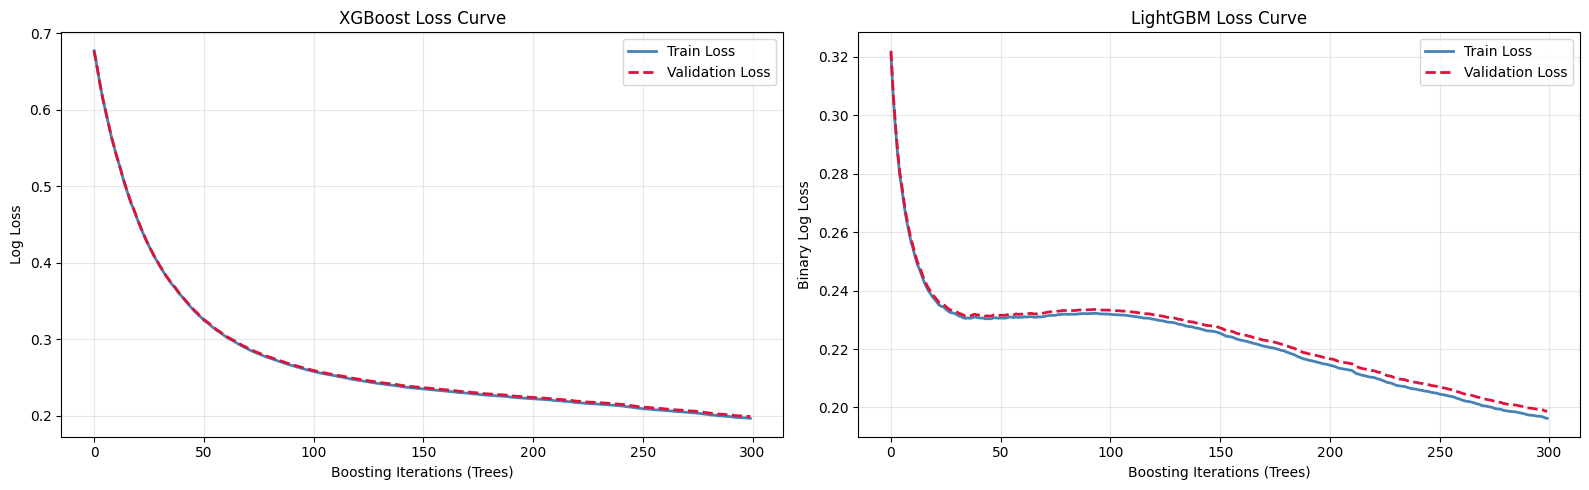

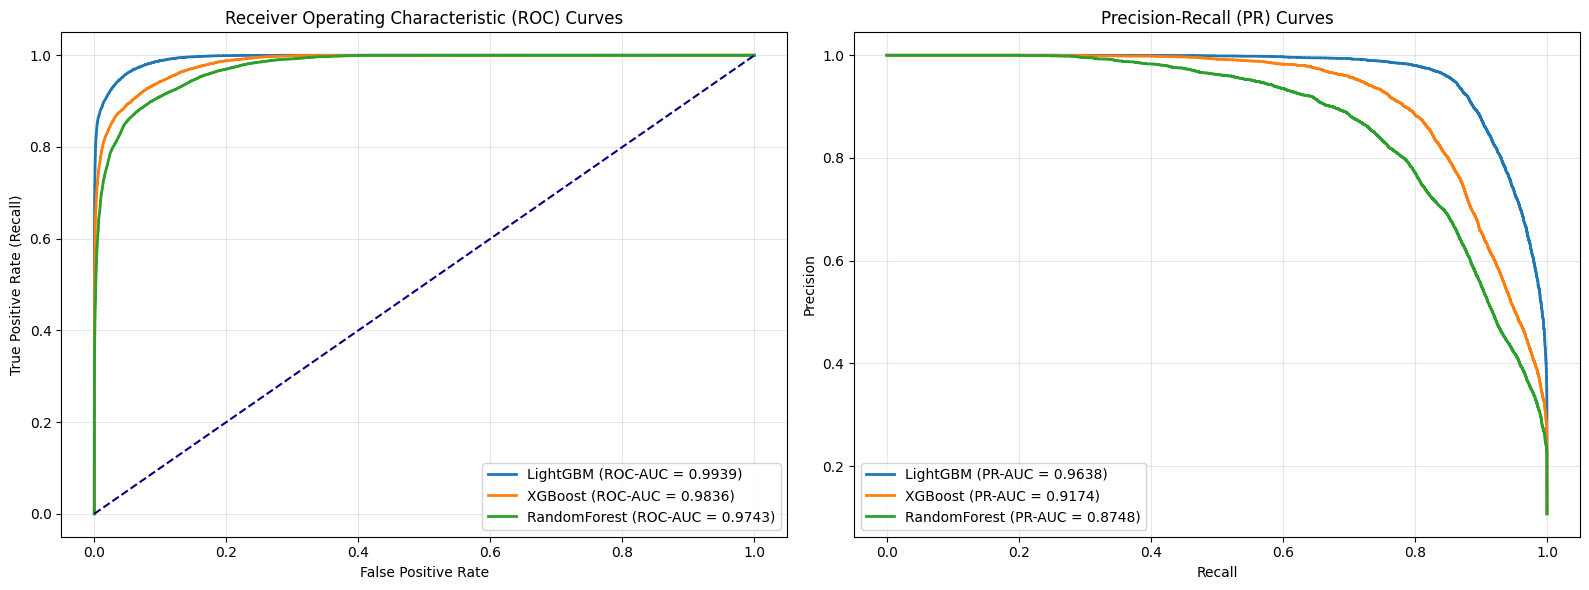


--- Decision Threshold Tuning (LightGBM) ---
Optimal Probability Threshold for Max F1: 0.7785
-------------------------------------------------------
  Accuracy @ Optimal Threshold:  0.9802
  Precision @ Optimal Threshold: 0.9474
  Recall @ Optimal Threshold:    0.8625
  F1-Score @ Optimal Threshold:  0.9030
  ROC-AUC Score:                0.9939
-------------------------------------------------------

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

           0     0.9837    0.9943    0.9890    133954
           1     0.9474    0.8625    0.9030     16046

    accuracy                         0.9802    150000
   macro avg     0.9655    0.9284    0.9460    150000
weighted avg     0.9798    0.9802    0.9798    150000



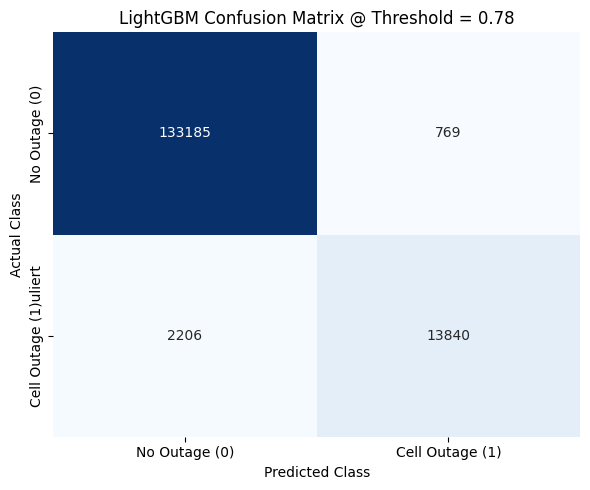


Champion model exported to /content/drive/MyDrive/models/champion_model.joblib


In [29]:
# =========================================================
# Section 3: Comprehensive Multi-Model Metrics Scorecard
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

# 1. Evaluate default (0.5 threshold) metrics across all models
model_scorecard = []

print("--- Computing Multi-Model Performance Metrics ---")
for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)

    model_scorecard.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, y_probs), 4)
    })

scorecard_df = pd.DataFrame(model_scorecard).sort_values(by='PR-AUC', ascending=False)

print("\n" + "="*70)
print("             OFFICIAL MULTI-MODEL PERFORMANCE SCORECARD            ")
print("="*70)
print(scorecard_df.to_string(index=False))

# =========================================================
# Section 4: Loss Curves (Training vs Validation Log-Loss)
# =========================================================

print("\n--- Training Loss Tracking Models ---")

# Re-fit XGBoost with evaluation history enabled
eval_xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, enable_categorical=True,
    tree_method='hist', random_state=42, n_jobs=-1,
    eval_metric='logloss'
)
eval_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Re-fit LightGBM with evaluation history enabled
eval_lgb = LGBMClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1,
    eval_metric='binary_logloss'
)
eval_lgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

# Plot Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot XGBoost Loss Curve
xgb_hist = eval_xgb.evals_result()
axes[0].plot(xgb_hist['validation_0']['logloss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(xgb_hist['validation_1']['logloss'], label='Validation Loss', color='crimson', lw=2, linestyle='--')
axes[0].set_xlabel('Boosting Iterations (Trees)')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('XGBoost Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot LightGBM Loss Curve
lgb_hist = eval_lgb.evals_result_
axes[1].plot(lgb_hist['training']['binary_logloss'], label='Train Loss', color='steelblue', lw=2)
axes[1].plot(lgb_hist['valid_1']['binary_logloss'], label='Validation Loss', color='crimson', lw=2, linestyle='--')
axes[1].set_xlabel('Boosting Iterations (Trees)')
axes[1].set_ylabel('Binary Log Loss')
axes[1].set_title('LightGBM Loss Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 5: ROC and Precision-Recall Curves Plotting
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in trained_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]

    # ROC Curves
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (ROC-AUC = {roc_auc_score(y_test, y_probs):.4f})')

    # PR Curves
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_probs):.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Section 6: Threshold Optimization & Confusion Matrix
# =========================================================

champion_name = scorecard_df.iloc[0]['Model']
champion_model = trained_models[champion_name]

print(f"\n--- Decision Threshold Tuning ({champion_name}) ---")
y_probs_champ = champion_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_champ)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

# Optimized Predictions
y_pred_optimal = (y_probs_champ >= optimal_threshold).astype(int)

opt_acc = accuracy_score(y_test, y_pred_optimal)
opt_prec = precisions[best_idx]
opt_rec = recalls[best_idx]
opt_f1 = f1_scores[best_idx]
opt_roc_auc = roc_auc_score(y_test, y_probs_champ)

print(f"Optimal Probability Threshold for Max F1: {optimal_threshold:.4f}")
print("-" * 55)
print(f"  Accuracy @ Optimal Threshold:  {opt_acc:.4f}")
print(f"  Precision @ Optimal Threshold: {opt_prec:.4f}")
print(f"  Recall @ Optimal Threshold:    {opt_rec:.4f}")
print(f"  F1-Score @ Optimal Threshold:  {opt_f1:.4f}")
print(f"  ROC-AUC Score:                {opt_roc_auc:.4f}")
print("-" * 55)

print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Outage (0)', 'Cell Outage (1)'],
            yticklabels=['No Outage (0)', 'Cell Outage (1)uliert']) # Label was 'Cell Outage (1)' so should be fine
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'{champion_name} Confusion Matrix @ Threshold = {optimal_threshold:.2f}')
plt.tight_layout()
plt.show()

# Export Champion Model Artifacts
joblib.dump({
    'model_name': champion_name,
    'model': champion_model,
    'threshold': optimal_threshold,
    'features': list(X_train.columns)
}, os.path.join(MODELS_DIR, 'champion_model.joblib'))

print(f"\nChampion model exported to {MODELS_DIR}/champion_model.joblib")


#Data Leakage check

In [30]:
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score

def run_data_leakage_audit(df, target_col='target', time_col=None, group_col=None):
    """
    Runs a comprehensive audit on a DataFrame to catch potential data leakage.

    Parameters:
    - df: pandas DataFrame containing raw or preprocessed features + target
    - target_col: str, the name of the target column
    - time_col: str (optional), timestamp column to check temporal ordering
    - group_col: str (optional), tower/cell ID column to check group-split overlap
    """
    print("=" * 70)
    print("                DATA LEAKAGE & INTEGRITY AUDIT REPORT               ")
    print("=" * 70)

    leakage_flags = 0
    features = [c for c in df.columns if c != target_col]

    # -------------------------------------------------------------------------
    # CHECK 1: Target Leakage via High Correlation / Mutual Information
    # -------------------------------------------------------------------------
    print("\n--- Check 1: Target Leakage (Features with Suspiciously High Signal) ---")
    suspicious_features = []

    for col in features:
        # Calculate Mutual Information for categorical & numerical
        if pd.api.types.is_numeric_dtype(df[col]):
            corr = abs(df[col].corr(df[target_col]))
            if corr > 0.85: # Threshold for near-perfect prediction
                suspicious_features.append((col, f"Correlation: {corr:.4f}"))
        else:
            # Categorical Mutual Information (Normalized)
            mi = mutual_info_score(df[col].astype(str), df[target_col].astype(str))
            if mi > 0.5:
                suspicious_features.append((col, f"Mutual Info: {mi:.4f}"))

    if suspicious_features:
        leakage_flags += 1
        print("⚠️ HIGH RISK: The following features have suspiciously high target alignment.")
        print("   (Check if these features are recorded AFTER an outage occurs!)\n")
        for feat, score in suspicious_features:
            print(f"   - {feat:<30} | {score}")
    else:
        print("✅ PASSED: No individual feature shows unrealistic correlation with target.")

    # -------------------------------------------------------------------------
    # CHECK 2: Metadata & Identifier Memorization
    # -------------------------------------------------------------------------
    print("\n--- Check 2: Unique ID & High-Cardinality Memorization Leakage ---")
    id_keywords = ['id', 'name', 'code', 'serial', 'index', 'key', 'address', 'ip']
    flagged_ids = []

    for col in features:
        # Check if column name sounds like an ID
        is_id_name = any(kw in col.lower() for kw in id_keywords)
        # Check if column has near-unique values per row
        unique_ratio = df[col].nunique() / len(df)

        if is_id_name or unique_ratio > 0.5:
            flagged_ids.append((col, f"Unique Ratio: {unique_ratio:.2%}"))

    if flagged_ids:
        leakage_flags += 1
        print("⚠️ WARNING: The following potential ID/Metadata features are still in 'X'.")
        print("   (Tree models can memorize these instead of learning general patterns!)\n")
        for col, info in flagged_ids:
            print(f"   - {col:<30} | {info}")
    else:
        print("✅ PASSED: No high-cardinality metadata/ID columns found in feature matrix.")

    # -------------------------------------------------------------------------
    # CHECK 3: Temporal Proximity / Time-Series Contamination
    # -------------------------------------------------------------------------
    if time_col and time_col in df.columns:
        print("\n--- Check 3: Time Horizon / Lead-Time Leakage ---")
        df_sorted = df.sort_values(by=time_col)

        if group_col and group_col in df.columns:
            # Check time delta between consecutive outage records for the same tower
            df_outages = df_sorted[df_sorted[target_col] == 1]
            df_outages['time_diff'] = df_outages.groupby(group_col)[time_col].diff()

            # Count records occurring within seconds/minutes of each other
            short_deltas = (df_outages['time_diff'] < pd.Timedelta(minutes=5)).sum()

            if short_deltas > 0:
                leakage_flags += 1
                print(f"⚠️ HIGH RISK: Found {short_deltas:,} failure rows occurring < 5 mins apart on the same cell.")
                print("   If using random K-Fold split, adjacent minutes of the same outage")
                print("   will land in BOTH Train and Test sets, causing massive artificial AUC scores!")
            else:
                print("✅ PASSED: Outage records on the same towers are well-separated in time.")
        else:
            print("ℹ️ SKIP: `group_col` not provided. Provide tower_id to check temporal proximity.")
    else:
        print("\n--- Check 3: Time Horizon ---")
        print("ℹ️ SKIP: `time_col` not provided. Pass a timestamp column to check temporal leakage.")

    # -------------------------------------------------------------------------
    # SUMMARY
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    if leakage_flags > 0:
        print(f"🚨 AUDIT FAILED: Found {leakage_flags} potential data leakage vector(s).")
        print("   Address the issues above before finalizing model evaluations.")
    else:
        print("🎉 AUDIT PASSED: No obvious data leakage detected!")
    print("=" * 70)

# =========================================================
# How to Run It On Your Dataset
# =========================================================
# Assume 'df' is your loaded pandas DataFrame

run_data_leakage_audit(
    df=df,
    target_col='target',        # Your binary output column (0 or 1)
    time_col='timestamp',       # (Optional) Your datetime column
    group_col='cell_id'        # (Optional) Your tower/cell identifier
)

                DATA LEAKAGE & INTEGRITY AUDIT REPORT               

--- Check 1: Target Leakage (Features with Suspiciously High Signal) ---
✅ PASSED: No individual feature shows unrealistic correlation with target.

--- Check 2: Unique ID & High-Cardinality Memorization Leakage ---
⚠️ WARNING: The following potential ID/Metadata features are still in 'X'.
   (Tree models can memorize these instead of learning general patterns!)

   - alarm_type_encoded             | Unique Ratio: 0.00%
   - severity_encoded               | Unique Ratio: 0.00%
   - mo_name_encoded                | Unique Ratio: 2.43%
   - alarm_name_encoded             | Unique Ratio: 0.05%

--- Check 3: Time Horizon ---
ℹ️ SKIP: `time_col` not provided. Pass a timestamp column to check temporal leakage.

🚨 AUDIT FAILED: Found 1 potential data leakage vector(s).
   Address the issues above before finalizing model evaluations.
